# Notebook 2 —  Models



| Section | Model |
|---|---|
| 1 | Random Walk |
| 2 | AR(1) |
| 3 | Rolling Average (4 weeks main / 8 and 12 appendix) |
| 4 | GBM Point Regressor — HistGradientBoostingRegressor (lag ablation) |
| 5 | Quantile GBM — 5th / 50th / 95th Percentile |
| 6 | Two-Stage Hurdle Model (lag ablation) |
| 7 | Long Short-Term Memory — single layer, 64 hidden units (sequence-length ablation) |





In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.ensemble import (HistGradientBoostingRegressor,
                               HistGradientBoostingClassifier)
from sklearn.preprocessing import OrdinalEncoder
from sklearn.inspection import permutation_importance as sk_perm_imp
from pathlib import Path

ROOT = Path('..')
SAVE = ROOT / 'results' / 'tables'

# ── Walk-forward splits (Z&T Section 4: fixed 291-week rolling window)
TRAIN_LEN  = 291
N_HOLDOUT  = 52
FIRST_TEST = 292

def rolling_week_splits():
    splits = []
    for step in range(N_HOLDOUT):
        test_week   = FIRST_TEST + step
        train_start = test_week - TRAIN_LEN
        splits.append((set(range(train_start, test_week)), test_week))
    return splits

# ── Feature engineering ───────────────────────────────────────────────────────
FEATURE_COLS = ['y', 'battles', 'explosions', 'strategic_dev', 'viol_civ']
N_LAGS       = 8

def build_tabular(panel):
    df = panel.copy().sort_values(['district', 'week_start']).reset_index(drop=True)
    for col in FEATURE_COLS:
        grp = df.groupby('district')[col]
        for k in range(1, N_LAGS + 1):
            df[f'{col}_lag{k}'] = grp.shift(k)
    df['week_of_year'] = df['week_start'].dt.isocalendar().week.astype(int)
    df['year']         = df['week_start'].dt.year
    lag_cols = [f'{col}_lag{k}' for col in FEATURE_COLS for k in range(1, N_LAGS + 1)]
    return df.dropna(subset=lag_cols).reset_index(drop=True)

def build_sequences(panel, seq_len=8):
    districts      = sorted(panel['district'].unique())
    district_index = {d: i for i, d in enumerate(districts)}
    seqs, dist_ids, targets, week_nums = [], [], [], []
    for district in districts:
        d_id  = district_index[district]
        sub   = (panel[panel['district'] == district]
                 .sort_values('week_start').reset_index(drop=True))
        vals  = sub[FEATURE_COLS].values
        wnums = sub['week_num'].values
        for t in range(seq_len, len(sub)):
            seqs.append(vals[t - seq_len : t])
            dist_ids.append(d_id)
            targets.append(float(vals[t, 0]))
            week_nums.append(int(wnums[t]))
    return {
        'X_seq'         : np.array(seqs,      dtype=np.float32),
        'X_dist'        : np.array(dist_ids,  dtype=np.int32),
        'y'             : np.array(targets,   dtype=np.float32),
        'week_num'      : np.array(week_nums, dtype=np.int32),
        'district_names': districts,
        'seq_len'       : seq_len,
    }

def feat_cols(n_lags):
    return ([f'{c}_lag{k}' for c in FEATURE_COLS for k in range(1, n_lags + 1)]
            + ['week_of_year', 'year'])

# ── LSTM architecture and training helpers ────────────────────────────────────
class LSTMForecaster(nn.Module):
    def __init__(self, n_features=5, n_districts=74, embed_dim=8, hidden=64):
        super().__init__()
        self.dist_embed = nn.Embedding(n_districts, embed_dim)
        self.lstm = nn.LSTM(input_size=n_features + embed_dim, hidden_size=hidden,
                            num_layers=1, batch_first=True)
        self.head = nn.Sequential(nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, x_seq, x_dist):
        emb = self.dist_embed(x_dist)
        emb = emb.unsqueeze(1).expand(-1, x_seq.size(1), -1)
        out, _ = self.lstm(torch.cat([x_seq, emb], dim=-1))
        return self.head(out[:, -1, :]).squeeze(-1)

def _standardise(X_train, X_test):
    mean = X_train.mean(axis=(0, 1), keepdims=True)
    std  = X_train.std(axis=(0, 1),  keepdims=True) + 1e-8
    return (X_train - mean) / std, (X_test - mean) / std

def _train_one_step(X_seq_tr, X_dist_tr, y_tr, X_seq_val, X_dist_val, y_val,
                    seq_len, seed, max_epochs=50, patience=10, batch_size=256):
    torch.manual_seed(seed); np.random.seed(seed)
    model   = LSTMForecaster(n_features=len(FEATURE_COLS))
    opt     = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    tr_dl   = DataLoader(
        TensorDataset(torch.tensor(X_seq_tr,  dtype=torch.float32),
                      torch.tensor(X_dist_tr, dtype=torch.long),
                      torch.tensor(y_tr,      dtype=torch.float32)),
        batch_size=batch_size, shuffle=True)
    val_seq  = torch.tensor(X_seq_val,  dtype=torch.float32)
    val_dist = torch.tensor(X_dist_val, dtype=torch.long)
    val_y    = torch.tensor(y_val,      dtype=torch.float32)
    best_val, best_state, no_imp = float('inf'), None, 0
    for _ in range(max_epochs):
        model.train()
        for xb, db, yb in tr_dl:
            opt.zero_grad(); loss_fn(model(xb, db), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            v = loss_fn(model(val_seq, val_dist), val_y).item()
        if v < best_val:
            best_val   = v
            best_state = {k: w.clone() for k, w in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= patience: break
    model.load_state_dict(best_state)
    return model

MODEL_COLORS = {
    'Random Walk'         : '#999999',
    'AR(1)'               : '#56B4E9',
    'Rolling Avg (4)'     : '#009E73',
    'Rolling Avg (8)'     : '#00836a',
    'Rolling Avg (12)'    : '#006452',
    'Long Run Mean'       : '#CCBB44',
    'Long Run Median'     : '#AA3377',
    'GBM (lags=1)'        : '#FFAA77',
    'GBM (lags=2)'        : '#FF8833',
    'GBM (lags=5)'        : '#D55E00',
    'GBM (lags=8)'        : '#A34400',
    'Quantile GBM'        : '#E69F00',
    'LSTM (seq=2)'        : '#CC79A7',
    'LSTM (seq=5)'        : '#9B3F80',
    'LSTM (seq=8)'        : '#6B1F55',
    'Hurdle (lags=2)'     : '#88CCEE',
    'Hurdle (lags=5)'     : '#0072B2',
    'Hurdle (lags=8)'     : '#004E80',
    'Z&T Bayesian DL-DLM' : '#000000',
}

# ── Point prediction metrics (per-week average)
def _rmse(yt, yp):  return float(np.sqrt(np.mean((yt - yp) ** 2)))
def _mae(yt, yp):   return float(np.mean(np.abs(yt - yp)))
def _smape(yt, yp):
    d = (np.abs(yt) + np.abs(yp)) / 2
    return float(np.mean(np.abs(yt - yp) / np.where(d < 1e-8, 1e-8, d)))
def _corr(yt, yp):
    return (0.0 if (np.std(yt) < 1e-9 or np.std(yp) < 1e-9)
            else float(np.corrcoef(yt, yp)[0, 1]))

def evaluate_point(df):
    rows = []
    for _, grp in df.groupby('week_num'):
        yt, yp = grp['y_true'].values, grp['y_pred'].values
        rows.append({'rmse':_rmse(yt,yp),'mae':_mae(yt,yp),
                     'smape':_smape(yt,yp),'corr':_corr(yt,yp)})
    pw = pd.DataFrame(rows)
    return {c: pw[c].mean() for c in pw.columns}

def global_rmse(df):
    return float(np.sqrt(np.mean((df['y_true'].values - df['y_pred'].values) ** 2)))

# ── Split-conformal prediction interval ────────────
def conformal_interval(cal_resid, pt, alpha=0.10):
    n     = len(cal_resid)
    level = min((1 - alpha) * (1 + 1/n), 1.0)
    q     = float(np.quantile(cal_resid, level))
    return max(0.0, pt - q), pt + q

# ── CRPS evaluation ───────────────────────────────────────────────


PROB_TAUS = np.array([0.05, 0.50, 0.95])           # conformal models
CRPS_TAUS = np.array([0.1, 0.2, 0.3, 0.4, 0.5,
                       0.6, 0.7, 0.8, 0.9])         # 9 deciles — Quantile GBM

def _pinball(y, q_hat, tau):
    e = y - q_hat
    return np.where(e >= 0, tau * e, (tau - 1) * e)

def empirical_crps(y_true, q05, q50, q95):
    y = np.asarray(y_true)
    q = np.column_stack([np.asarray(q05), np.asarray(q50), np.asarray(q95)])
    t = PROB_TAUS.reshape(1, -1)
    diff    = y.reshape(-1, 1) - q
    pinball = np.where(diff >= 0, t * diff, (t - 1) * diff)
    return 2.0 * pinball.mean(axis=1)

def empirical_crps_deciles(df):
    y      = df['y_true'].values
    scores = np.zeros(len(y))
    for tau in CRPS_TAUS:
        col    = f'q{int(round(tau * 100)):02d}'
        scores += _pinball(y, df[col].values, tau)
    return (2 / len(CRPS_TAUS)) * scores

def evaluate_probabilistic(df):
    yt        = df['y_true'].values
    crps_vals = empirical_crps(yt, df['q05'].values, df['q50'].values, df['q95'].values)
    return {
        'crps'    : float(crps_vals.mean()),
        'coverage': float(np.mean((yt >= df['q05'].values) & (yt <= df['q95'].values))),
        'width'   : float((df['q95'].values - df['q05'].values).mean()),
    }

def evaluate_qgbm(df):
    yt        = df['y_true'].values
    crps_vals = empirical_crps_deciles(df)
    return {
        'crps'    : float(crps_vals.mean()),
        'coverage': float(np.mean((yt >= df['q05'].values) & (yt <= df['q95'].values))),
        'width'   : float((df['q95'].values - df['q05'].values).mean()),
    }

print('Setup complete.')


Setup complete.


---
## Load Data and Walk-Forward Splits


In [62]:
panel   = pd.read_parquet(ROOT / 'data' / 'processed' / 'panel.parquet')
tabular = build_tabular(panel)
splits  = rolling_week_splits()

ENCODER = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
ENCODER.fit(tabular[['district']])

point_preds = {}   # model_name -> DataFrame(week_num, district, y_true, y_pred)
prob_preds  = {}   # model_name -> DataFrame(+ q05, q50, q95)

TEST_WEEKS = set(range(292, 344))
y_test_all = tabular[tabular['week_num'].isin(TEST_WEEKS)]['y'].values
SS_tot     = float(np.sum((y_test_all - y_test_all.mean()) ** 2))
n_test     = len(y_test_all)

print(f'Panel   : {panel.shape}')
print(f'Tabular : {tabular.shape}')
print(f'Splits  : {len(splits)} walk-forward steps')
print(f'y_test  : n={n_test}, mean={y_test_all.mean():.3f}, std={y_test_all.std():.3f}')


Panel   : (25382, 9)
Tabular : (24790, 51)
Splits  : 52 walk-forward steps
y_test  : n=3848, mean=3.295, std=2.634


---
## 1. Random Walk




In [63]:
records = []
for train_weeks, test_week in splits:
    cal_weeks = sorted(train_weeks)[-26:]
    cal       = tabular[tabular['week_num'].isin(cal_weeks)].copy()
    cal_resid = np.abs(cal['y'].values - cal['y_lag1'].fillna(0).clip(lower=0).values)

    test = tabular[tabular['week_num'] == test_week]
    for _, row in test.iterrows():
        pt       = max(0.0, float(row['y_lag1']))
        q05, q95 = conformal_interval(cal_resid, pt)
        records.append({'week_num': test_week, 'district': row['district'],
                        'y_true': row['y'], 'y_pred': pt,
                        'q05': q05, 'q50': pt, 'q95': q95})

rw_preds = pd.DataFrame(records)
point_preds['Random Walk'] = rw_preds
prob_preds['Random Walk']  = rw_preds
print(f'Random Walk: {len(rw_preds)} predictions')


Random Walk: 3848 predictions


---
## 2. AR(1)



In [64]:
districts = sorted(tabular['district'].unique())
records   = []

for train_weeks, test_week in splits:
    train     = tabular[tabular['week_num'].isin(train_weeks)]
    cal_weeks = sorted(train_weeks)[-26:]

    coefs = {}
    for d in districts:
        sub = train[train['district'] == d][['y_lag1', 'y']].dropna()
        if len(sub) < 3:
            coefs[d] = (0.0, 1.0); continue
        A      = np.column_stack([np.ones(len(sub)), sub['y_lag1'].values])
        c, *_  = np.linalg.lstsq(A, sub['y'].values, rcond=None)
        coefs[d] = (float(c[0]), float(c[1]))

    def _ar1(row):
        a, b = coefs.get(row['district'], (0.0, 1.0))
        return max(0.0, a + b * float(row['y_lag1']))

    cal       = tabular[tabular['week_num'].isin(cal_weeks)]
    cal_resid = np.array([abs(row['y'] - _ar1(row)) for _, row in cal.iterrows()])

    test = tabular[tabular['week_num'] == test_week]
    for _, row in test.iterrows():
        pt       = _ar1(row)
        q05, q95 = conformal_interval(cal_resid, pt)
        records.append({'week_num': test_week, 'district': row['district'],
                        'y_true': row['y'], 'y_pred': pt,
                        'q05': q05, 'q50': pt, 'q95': q95})

ar1_preds = pd.DataFrame(records)
point_preds['AR(1)'] = ar1_preds
prob_preds['AR(1)']  = ar1_preds
print(f'AR(1): {len(ar1_preds)} predictions')


AR(1): 3848 predictions


---
## 3. Rolling Average (4, 8 and 12 Weeks)




In [65]:
def run_rolling(tabular, splits, window):
    records = []
    for train_weeks, test_week in splits:
        recent = sorted(train_weeks)[-window:]
        means  = tabular[tabular['week_num'].isin(recent)].groupby('district')['y'].mean()
        for _, row in tabular[tabular['week_num'] == test_week].iterrows():
            records.append({'week_num': test_week, 'district': row['district'],
                            'y_true': row['y'],
                            'y_pred': float(means.get(row['district'], 0.0))})
    return pd.DataFrame(records)

print('Running Rolling Avg (4) ...')
point_preds['Rolling Avg (4)']  = run_rolling(tabular, splits, 4)
print('Running Rolling Avg (8) ...')
point_preds['Rolling Avg (8)']  = run_rolling(tabular, splits, 8)
print('Running Rolling Avg (12) ...')
point_preds['Rolling Avg (12)'] = run_rolling(tabular, splits, 12)
print('Done.')


Running Rolling Avg (4) ...
Running Rolling Avg (8) ...
Running Rolling Avg (12) ...
Done.



## 4. GBM Point Regressor — HistGradientBoostingRegressor (Lag Ablation)



In [67]:
def run_gbm(tabular, splits, n_lags):
    fc = feat_cols(n_lags)
    records = []
    for step_idx, (train_weeks, test_week) in enumerate(splits):
        if (step_idx + 1) % 10 == 0:
            print(f'    step {step_idx+1}/52 ...')
        ptr  = tabular[tabular['week_num'].isin(train_weeks)].dropna(subset=fc)
        test = tabular[tabular['week_num'] == test_week].dropna(subset=fc)
        if len(ptr) == 0 or len(test) == 0: continue
        X_ptr  = np.hstack([ENCODER.transform(ptr[['district']]),  ptr[fc].values])
        X_test = np.hstack([ENCODER.transform(test[['district']]), test[fc].values])
        model = HistGradientBoostingRegressor(
            loss='squared_error', max_iter=500, learning_rate=0.05,
            max_leaf_nodes=31, min_samples_leaf=20, random_state=42)
        model.fit(X_ptr, ptr['y'].values)
        for (_, row), pt in zip(test.iterrows(),
                                 np.clip(model.predict(X_test), 0, None)):
            records.append({'week_num': test_week, 'district': row['district'],
                            'y_true': row['y'], 'y_pred': float(pt)})
    return pd.DataFrame(records)

for n_lags, label in [(1,'GBM (lags=1)'), (2,'GBM (lags=2)'),
                       (5,'GBM (lags=5)'), (8,'GBM (lags=8)')]:
    print(f'Running {label} ...')
    point_preds[label] = run_gbm(tabular, splits, n_lags)
print('Done.')


Running GBM (lags=1) ...
    step 10/52 ...
    step 20/52 ...
    step 30/52 ...
    step 40/52 ...
    step 50/52 ...
Running GBM (lags=2) ...
    step 10/52 ...
    step 20/52 ...
    step 30/52 ...
    step 40/52 ...
    step 50/52 ...
Running GBM (lags=5) ...
    step 10/52 ...
    step 20/52 ...
    step 30/52 ...
    step 40/52 ...
    step 50/52 ...
Running GBM (lags=8) ...
    step 10/52 ...
    step 20/52 ...
    step 30/52 ...
    step 40/52 ...
    step 50/52 ...
Done.


#### GBM Feature Importance (fitted on final training window)


In [68]:
fc5 = feat_cols(5)
last_train_weeks, last_test_week = splits[-1]
last_train = tabular[tabular['week_num'].isin(last_train_weeks)].dropna(subset=fc5)
last_test  = tabular[tabular['week_num'] == last_test_week].dropna(subset=fc5)

X_last = np.hstack([ENCODER.transform(last_train[['district']]), last_train[fc5].values])
gbm_final = HistGradientBoostingRegressor(
    loss='squared_error', max_iter=500, learning_rate=0.05,
    max_leaf_nodes=31, min_samples_leaf=20, random_state=42)
gbm_final.fit(X_last, last_train['y'].values)

X_te_last = np.hstack([ENCODER.transform(last_test[['district']]), last_test[fc5].values])
perm = sk_perm_imp(gbm_final, X_te_last, last_test['y'].values,
                    n_repeats=10, random_state=42, scoring='neg_mean_squared_error')
imp_df = pd.DataFrame({'feature': ['district'] + fc5,
                        'importance': perm.importances_mean,
                        'std': perm.importances_std})\
           .sort_values('importance', ascending=False)
print(imp_df.head(20).to_string(index=False))


           feature  importance      std
            y_lag1    0.875333 0.248708
            y_lag3    0.386705 0.133794
            y_lag2    0.314727 0.120789
            y_lag5    0.100996 0.084892
            y_lag4    0.046691 0.122614
          district    0.031225 0.040988
strategic_dev_lag4    0.019433 0.005899
strategic_dev_lag5    0.018784 0.003663
   explosions_lag2    0.005701 0.004946
   explosions_lag1    0.005487 0.017144
strategic_dev_lag3    0.002581 0.003536
strategic_dev_lag1    0.002536 0.011393
     viol_civ_lag3    0.001622 0.003536
     viol_civ_lag1    0.000915 0.006062
      battles_lag1    0.000325 0.013963
      week_of_year    0.000000 0.000000
              year    0.000000 0.000000
      battles_lag5   -0.000155 0.018620
     viol_civ_lag5   -0.000337 0.007593
     viol_civ_lag2   -0.002612 0.007210


---
## 5. Quantile GBM (Probabilistic Model)




In [69]:
# Quantile levels: 9 deciles for CRPS + outer bounds for 90% interval
QGBM_TAUS = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

fc5     = feat_cols(5)
records = []
BASE    = dict(max_iter=500, learning_rate=0.05,
               max_leaf_nodes=31, min_samples_leaf=20, random_state=42)

for step_idx, (train_weeks, test_week) in enumerate(splits):
    if (step_idx + 1) % 10 == 0:
        print(f'    step {step_idx+1}/52 ...')

    train = tabular[tabular['week_num'].isin(train_weeks)].dropna(subset=fc5)
    test  = tabular[tabular['week_num'] == test_week].dropna(subset=fc5)
    if len(train) == 0 or len(test) == 0: continue

    X_tr = np.hstack([ENCODER.transform(train[['district']]), train[fc5].values])
    X_te = np.hstack([ENCODER.transform(test[['district']]),  test[fc5].values])
    y_tr = train['y'].values

    # Train one model per quantile level (11 total)
    models = {
        tau: HistGradientBoostingRegressor(loss='quantile', quantile=tau, **BASE)
        for tau in QGBM_TAUS
    }
    for m in models.values():
        m.fit(X_tr, y_tr)

    q_preds = {tau: np.clip(m.predict(X_te), 0, None) for tau, m in models.items()}

    for i, (_, row) in enumerate(test.iterrows()):
        rec = {
            'week_num': test_week, 'district': row['district'],
            'y_true'  : row['y'],
            'y_pred'  : float(q_preds[0.50][i]),
            'q05'     : float(q_preds[0.05][i]),
            'q50'     : float(q_preds[0.50][i]),
            'q95'     : float(q_preds[0.95][i]),
        }
        # Decile columns for empirical CRPS
        for tau in CRPS_TAUS:
            rec[f'q{int(round(tau * 100)):02d}'] = float(q_preds[tau][i])
        records.append(rec)

qgbm = pd.DataFrame(records)
point_preds['Quantile GBM'] = qgbm
prob_preds['Quantile GBM']  = qgbm
print(f'Quantile GBM: {len(qgbm)} predictions  ({len(QGBM_TAUS)} quantiles × 52 steps)')


    step 10/52 ...
    step 20/52 ...
    step 30/52 ...
    step 40/52 ...
    step 50/52 ...
Quantile GBM: 3848 predictions  (11 quantiles × 52 steps)


---
# 6. Two-Stage Hurdle Model



In [70]:
def run_hurdle(tabular, splits, n_lags, with_prob=False):
    fc = feat_cols(n_lags)
    records = []
    for step_idx, (train_weeks, test_week) in enumerate(splits):
        if (step_idx + 1) % 10 == 0:
            print(f'    step {step_idx+1}/52 ...')

        ptr_weeks = sorted(train_weeks)[:-26] if with_prob else list(train_weeks)
        ptr  = tabular[tabular['week_num'].isin(ptr_weeks)].dropna(subset=fc)
        test = tabular[tabular['week_num'] == test_week].dropna(subset=fc)
        if len(ptr) == 0 or len(test) == 0: continue

        X_ptr = np.hstack([ENCODER.transform(ptr[['district']]),  ptr[fc].values])
        X_te  = np.hstack([ENCODER.transform(test[['district']]), test[fc].values])
        z_ptr = (ptr['y'].values > 0).astype(int)

        clf = HistGradientBoostingClassifier(
            max_iter=300, learning_rate=0.05,
            max_leaf_nodes=31, min_samples_leaf=20, random_state=42)
        clf.fit(X_ptr, z_ptr)

        nz  = ptr['y'].values > 0
        reg = HistGradientBoostingRegressor(
            loss='squared_error', max_iter=500, learning_rate=0.05,
            max_leaf_nodes=31, min_samples_leaf=10, random_state=42)
        if nz.sum() >= 10:
            reg.fit(X_ptr[nz], ptr['y'].values[nz])
            te_count = np.clip(reg.predict(X_te), 0, None)
        else:
            te_count = np.zeros(len(X_te))

        te_preds = np.clip(clf.predict_proba(X_te)[:, 1] * te_count, 0, None)

        cal_resid = None
        if with_prob:
            cal_weeks = sorted(train_weeks)[-26:]
            cal       = tabular[tabular['week_num'].isin(cal_weeks)].dropna(subset=fc)
            X_cal     = np.hstack([ENCODER.transform(cal[['district']]), cal[fc].values])
            cal_cnt   = (np.clip(reg.predict(X_cal), 0, None) if nz.sum() >= 10
                         else np.zeros(len(X_cal)))
            cal_preds  = np.clip(clf.predict_proba(X_cal)[:, 1] * cal_cnt, 0, None)
            cal_resid  = np.abs(cal['y'].values - cal_preds)

        for (_, row), pt in zip(test.iterrows(), te_preds):
            rec = {'week_num': test_week, 'district': row['district'],
                   'y_true': row['y'], 'y_pred': float(pt)}
            if with_prob:
                q05, q95 = conformal_interval(cal_resid, float(pt))
                rec.update({'q05': q05, 'q50': float(pt), 'q95': q95})
            records.append(rec)
    return pd.DataFrame(records)

print('Running Hurdle (lags=2) ...')
point_preds['Hurdle (lags=2)'] = run_hurdle(tabular, splits, 2)
print('Running Hurdle (lags=5) ...')
point_preds['Hurdle (lags=5)'] = run_hurdle(tabular, splits, 5)
print('Running Hurdle (lags=8) with conformal intervals ...')
h8 = run_hurdle(tabular, splits, 8, with_prob=True)
point_preds['Hurdle (lags=8)'] = h8
prob_preds['Hurdle (lags=8)']  = h8
print('Done.')


Running Hurdle (lags=2) ...
    step 10/52 ...
    step 20/52 ...
    step 30/52 ...
    step 40/52 ...
    step 50/52 ...
Running Hurdle (lags=5) ...
    step 10/52 ...
    step 20/52 ...
    step 30/52 ...
    step 40/52 ...
    step 50/52 ...
Running Hurdle (lags=8) with conformal intervals ...
    step 10/52 ...
    step 20/52 ...
    step 30/52 ...
    step 40/52 ...
    step 50/52 ...
Done.


---
## 7. Long Short-Term Memory 



**Architecture:** 
`Embedding(74, 8)` → `LSTM(input=13, hidden=64)` → `Linear(64→32)` → `ReLU` → `Linear(32→1)`
**Training:** MSE loss, Adam 

In [71]:
def run_lstm(panel, splits, seq_len, seed=42):
    seqs           = build_sequences(panel, seq_len=seq_len)
    X_seq_all      = seqs['X_seq']
    X_dist_all     = seqs['X_dist']
    y_all          = seqs['y']
    week_all       = seqs['week_num']
    district_names = seqs['district_names']
    records = []

    for step_idx, (train_weeks, test_week) in enumerate(splits):
        if (step_idx + 1) % 10 == 0:
            print(f'    step {step_idx+1}/52  seq={seq_len} ...')

        tr_mask  = np.isin(week_all, list(train_weeks))
        te_mask  = week_all == test_week
        val_mask = np.isin(week_all, sorted(train_weeks)[-26:])
        ptr_mask = tr_mask & ~val_mask
        if ptr_mask.sum() == 0 or te_mask.sum() == 0: continue

        X_tr_n, X_vn = _standardise(X_seq_all[ptr_mask], X_seq_all[val_mask])
        _,      X_ten = _standardise(X_seq_all[ptr_mask], X_seq_all[te_mask])

        model = _train_one_step(
            X_tr_n, X_dist_all[ptr_mask], y_all[ptr_mask],
            X_vn,   X_dist_all[val_mask],  y_all[val_mask],
            seq_len=seq_len, seed=seed)
        model.eval()
        with torch.no_grad():
            preds = np.clip(model(
                torch.tensor(X_ten,               dtype=torch.float32),
                torch.tensor(X_dist_all[te_mask], dtype=torch.long),
            ).numpy(), 0, None)

        for dist, y_t, pt in zip([district_names[i] for i in X_dist_all[te_mask]],
                                   y_all[te_mask], preds):
            records.append({'week_num': test_week, 'district': dist,
                            'y_true': float(y_t), 'y_pred': float(pt)})
    return pd.DataFrame(records)

for seq_len, label in [(2,'LSTM (seq=2)'), (5,'LSTM (seq=5)'), (8,'LSTM (seq=8)')]:
    print(f'Running {label} ...')
    point_preds[label] = run_lstm(panel, splits, seq_len)
print('Done.')


Running LSTM (seq=2) ...
    step 10/52  seq=2 ...
    step 20/52  seq=2 ...
    step 30/52  seq=2 ...
    step 40/52  seq=2 ...
    step 50/52  seq=2 ...
Running LSTM (seq=5) ...
    step 10/52  seq=5 ...
    step 20/52  seq=5 ...
    step 30/52  seq=5 ...
    step 40/52  seq=5 ...
    step 50/52  seq=5 ...
Running LSTM (seq=8) ...
    step 10/52  seq=8 ...
    step 20/52  seq=8 ...
    step 30/52  seq=8 ...
    step 40/52  seq=8 ...
    step 50/52  seq=8 ...
Done.


---
## 8. Point Prediction Results

RMSE, MAE, and sMAPE relative to Random Walk (ratio < 1 = better).
Correlation and R\u00b2 as absolute values. Z&T benchmark row added for comparison.


In [74]:
POINT_ORDER = [
    'Random Walk', 'AR(1)', 'Rolling Avg (4)', 'Rolling Avg (8)', 'Rolling Avg (12)',

    'GBM (lags=1)', 'GBM (lags=2)', 'GBM (lags=5)', 'GBM (lags=8)',
    'Quantile GBM',
    'LSTM (seq=2)', 'LSTM (seq=5)', 'LSTM (seq=8)',
    'Hurdle (lags=2)', 'Hurdle (lags=5)', 'Hurdle (lags=8)',
]

raw_pt = {n: evaluate_point(df) for n, df in point_preds.items()}
rw_pt  = raw_pt['Random Walk']

rows = []
for name in POINT_ORDER:
    if name not in raw_pt: continue
    m  = raw_pt[name]
    df = point_preds[name]
    r2 = round(1 - n_test * global_rmse(df)**2 / SS_tot, 3)
    rows.append({
        'Model': name,
        'RMSE' : round(m['rmse']  / rw_pt['rmse'],  3),
        'MAE'  : round(m['mae']   / rw_pt['mae'],   3),
        'sMAPE': round(m['smape'] / rw_pt['smape'], 3),
        'Corr' : round(m['corr'], 3),
        'R²'   : r2,
    })
rows.append({'Model':'Z&T Bayesian DL-DLM',
             'RMSE':0.737,'MAE':0.907,'sMAPE':0.804,'Corr':0.639,'R²':None})

point_table = pd.DataFrame(rows)
print('=== Point Prediction Results (relative to Random Walk) ===')
print(point_table.to_string(index=False))
point_table.to_csv(SAVE / 'point_results_final.csv', index=False)
print('\nSaved point_results_final.csv')


=== Point Prediction Results (relative to Random Walk) ===
              Model  RMSE   MAE  sMAPE  Corr    R²
        Random Walk 1.000 1.000  1.000 0.640 0.282
              AR(1) 0.883 1.073  1.568 0.682 0.443
    Rolling Avg (4) 0.853 0.937  1.173 0.709 0.476
    Rolling Avg (8) 0.865 0.991  1.330 0.701 0.459
   Rolling Avg (12) 0.889 1.041  1.418 0.683 0.429
       GBM (lags=1) 0.854 1.005  1.477 0.698 0.477
       GBM (lags=2) 0.842 0.987  1.487 0.709 0.492
       GBM (lags=5) 0.824 0.958  1.494 0.719 0.511
       GBM (lags=8) 0.825 0.959  1.492 0.720 0.510
       Quantile GBM 0.843 0.904  1.527 0.708 0.488
       LSTM (seq=2) 0.863 1.047  1.531 0.692 0.467
       LSTM (seq=5) 0.833 0.996  1.503 0.716 0.503
       LSTM (seq=8) 0.835 0.997  1.502 0.715 0.499
    Hurdle (lags=2) 0.846 0.981  1.508 0.702 0.487
    Hurdle (lags=5) 0.829 0.961  1.501 0.715 0.506
    Hurdle (lags=8) 0.834 0.986  1.496 0.716 0.500
Z&T Bayesian DL-DLM 0.737 0.907  0.804 0.639   NaN

Saved point_results_fi

---
## 9. Probabilistic Results





In [75]:
PROB_ORDER = ['Random Walk', 'AR(1)', 'Quantile GBM', 'Hurdle (lags=8)']

raw_prob = {
    n: (evaluate_qgbm(df) if n == 'Quantile GBM'
        else evaluate_probabilistic(df))
    for n, df in prob_preds.items()
}
rw_crps  = raw_prob['Random Walk']['crps']

rows = []
for name in PROB_ORDER:
    if name not in raw_prob: continue
    m  = raw_prob[name]
    df = prob_preds[name]
    r2 = round(1 - n_test * global_rmse(df)**2 / SS_tot, 3)
    rows.append({
        'Model'       : name,
        'CRPS'        : round(m['crps'], 4),
        'Rel. CRPS'   : round(m['crps'] / rw_crps, 3),
        'Coverage 90%': round(m['coverage'], 3),
        'Width'       : round(m['width'], 4),
        'R²'          : r2,
    })

prob_table = pd.DataFrame(rows)
print('=== Probabilistic Results (Empirical CRPS via pinball decomposition) ===')
print(prob_table.to_string(index=False))
prob_table.to_csv(SAVE / 'prob_results_final.csv', index=False)
print('\nSaved prob_results_final.csv')


=== Probabilistic Results (Empirical CRPS via pinball decomposition) ===
          Model   CRPS  Rel. CRPS  Coverage 90%  Width    R²
    Random Walk 0.7833      1.000         0.902 6.5799 0.282
          AR(1) 0.7677      0.980         0.900 5.6407 0.443
   Quantile GBM 1.0708      1.367         0.925 5.7929 0.488
Hurdle (lags=8) 0.7209      0.920         0.903 5.6818 0.500

Saved prob_results_final.csv


---
## 10. Figures


### Figure 1 — Point Prediction Accuracy (Relative RMSE)


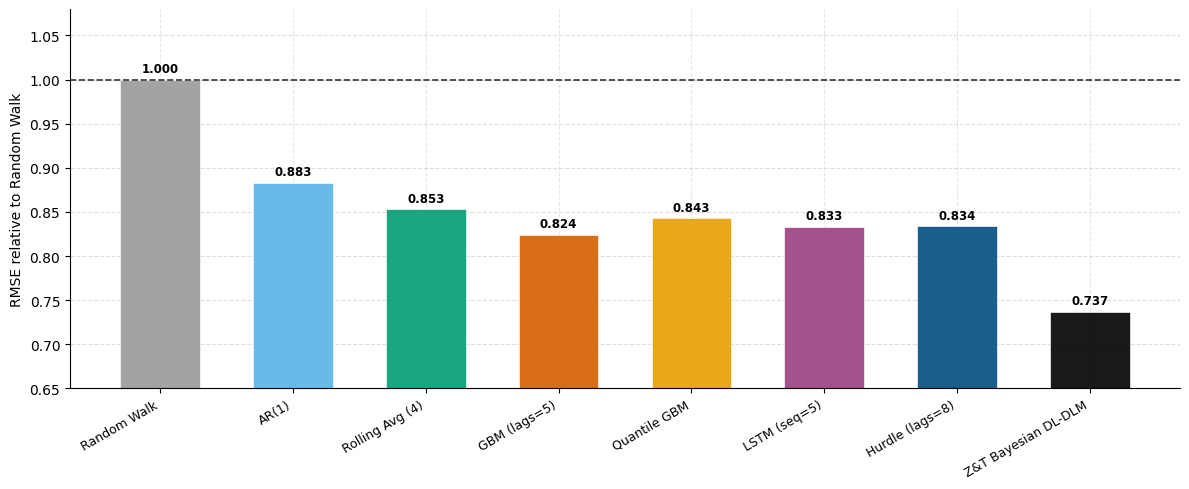

Saved fig_rmse_final.png


In [79]:
plt.rcParams.update({'font.family':'DejaVu Sans','axes.spines.top':False,
                     'axes.spines.right':False,'axes.grid':True,
                     'grid.alpha':0.3,'grid.linestyle':'--'})

MAIN_MODELS = ['Random Walk','AR(1)','Rolling Avg (4)','GBM (lags=5)',
               'Quantile GBM','LSTM (seq=5)','Hurdle (lags=8)','Z&T Bayesian DL-DLM']
pt_main = point_table[point_table['Model'].isin(MAIN_MODELS)].copy()
pt_main['color'] = pt_main['Model'].map(MODEL_COLORS)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(pt_main)), pt_main['RMSE'],
              color=pt_main['color'], width=0.6, alpha=0.90,
              edgecolor='white', linewidth=0.5)
ax.axhline(1.0, color='#333333', lw=1.2, ls='--', zorder=5)
for bar, val in zip(bars, pt_main['RMSE']):
    if pd.notna(val):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_xticks(range(len(pt_main)))
ax.set_xticklabels(pt_main['Model'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('RMSE relative to Random Walk', fontsize=10)
ax.set_ylim(0.65, 1.08)

ax.yaxis.grid(True, linestyle='--', alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout()
fig.savefig(SAVE / 'fig_rmse_final.png', dpi=160, bbox_inches='tight')
plt.show()
print('Saved fig_rmse_final.png')


### Figure 2 — Probabilistic Forecast Quality (Relative CRPS)


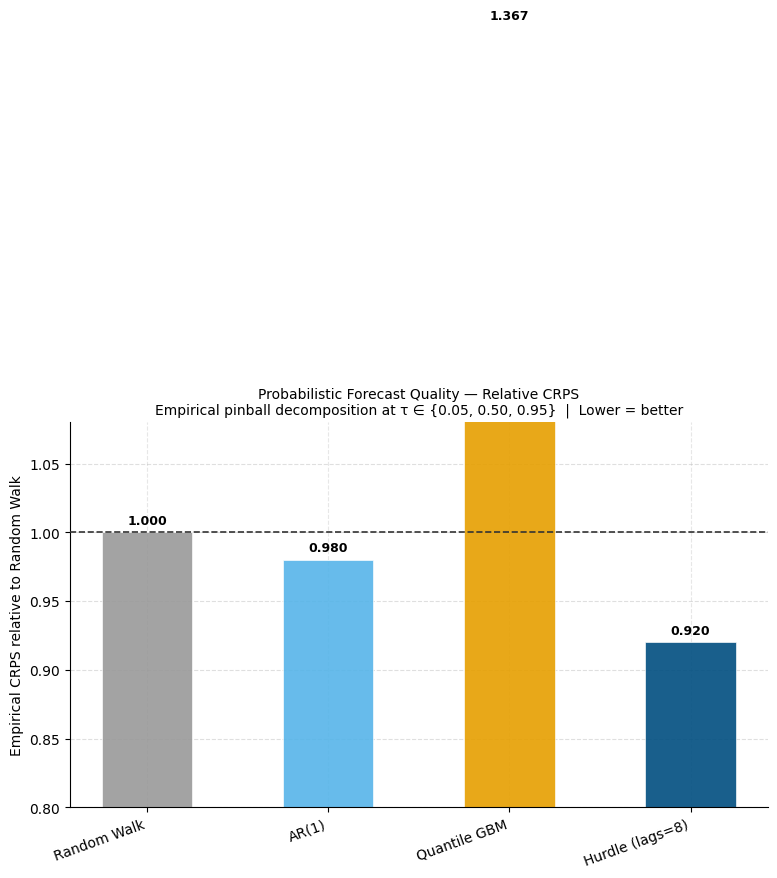

Saved fig_crps_final.png


In [81]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(range(len(prob_table)), prob_table['Rel. CRPS'],
              color=[MODEL_COLORS.get(m,'#aaa') for m in prob_table['Model']],
              width=0.5, alpha=0.90, edgecolor='white', linewidth=0.5)
ax.axhline(1.0, color='#333333', lw=1.2, ls='--', zorder=5)
for bar, val in zip(bars, prob_table['Rel. CRPS']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(prob_table)))
ax.set_xticklabels(prob_table['Model'], rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Empirical CRPS relative to Random Walk', fontsize=10)
ax.set_ylim(0.80, 1.08)
ax.set_title('Probabilistic Forecast Quality — Relative CRPS\n'
             'Empirical pinball decomposition at \u03c4 ∈ {0.05, 0.50, 0.95}  |  Lower = better',
             fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.4); ax.set_axisbelow(True)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(SAVE / 'fig_crps_final.png', dpi=160, bbox_inches='tight')
plt.show()
print('Saved fig_crps_final.png')


### Figure 4 — 90% Prediction Intervals (Belet Weyne)


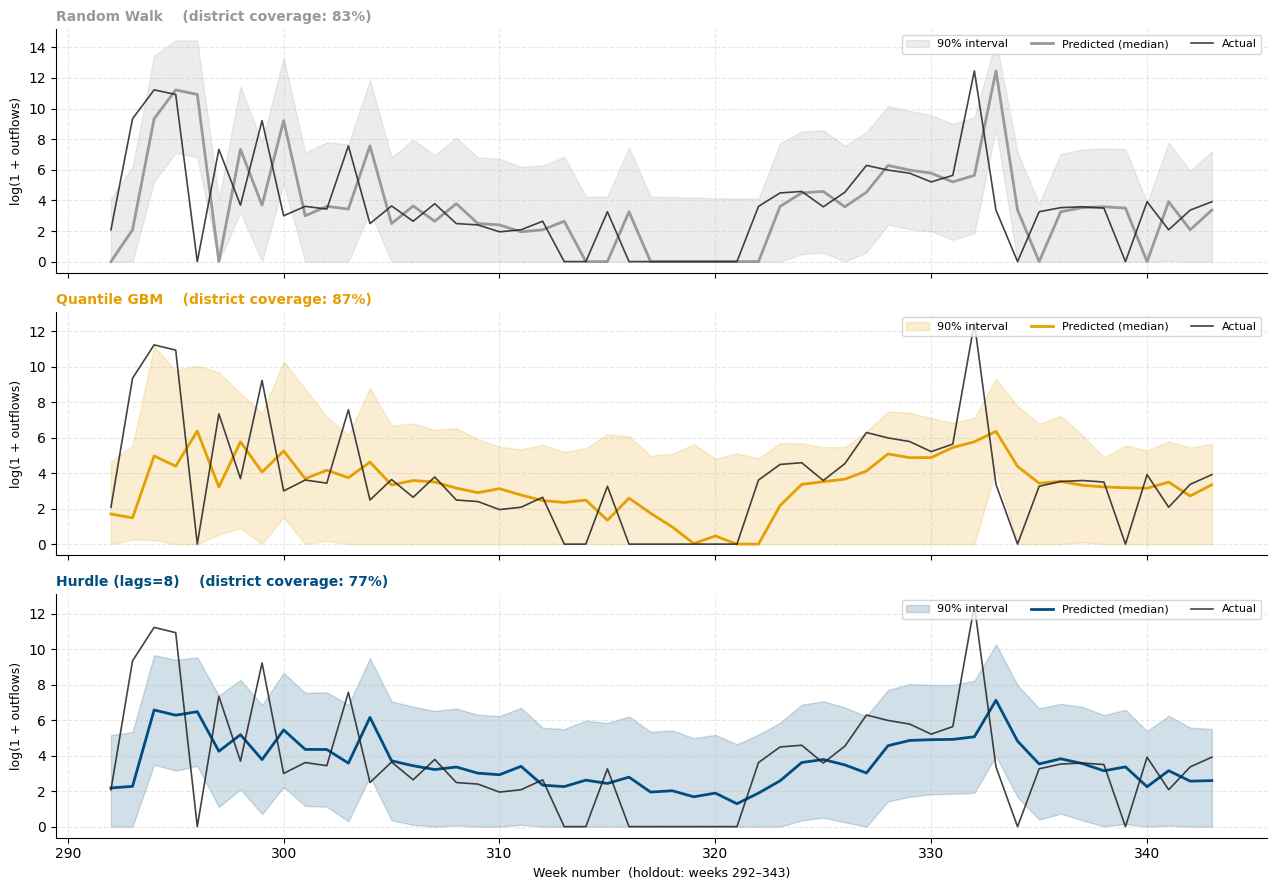

Saved fig_intervals_final.png


In [82]:
DISTRICT = 'Belet Weyne'
SHOW = [
    ('Random Walk',    prob_preds['Random Walk']),
    ('Quantile GBM',   prob_preds['Quantile GBM']),
    ('Hurdle (lags=8)',prob_preds['Hurdle (lags=8)']),
]
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, (name, df) in zip(axes, SHOW):
    d     = df[df['district'] == DISTRICT].sort_values('week_num')
    color = MODEL_COLORS[name]
    upper = np.minimum(d['q95'].values, d['y_true'].max() + 2)
    ax.fill_between(d['week_num'], d['q05'].values, upper,
                    alpha=0.18, color=color, label='90% interval')
    ax.plot(d['week_num'], d['q50'].values, color=color, lw=2.0,
            label='Predicted (median)', zorder=3)
    ax.plot(d['week_num'], d['y_true'], color='#222222', lw=1.2,
            alpha=0.85, label='Actual', zorder=4)
    inside = ((d['y_true'] >= d['q05']) & (d['y_true'] <= d['q95'])).mean()
    ax.set_title(f'{name}    (district coverage: {inside:.0%})',
                 fontsize=10, fontweight='bold', color=color, loc='left')
    ax.set_ylabel('log(1 + outflows)', fontsize=9)
    ax.legend(fontsize=8, loc='upper right', ncol=3, framealpha=0.8)
    ax.yaxis.grid(True, ls='--', alpha=0.3)
axes[-1].set_xlabel('Week number  (holdout: weeks 292–343)', fontsize=9)

plt.tight_layout()
fig.savefig(SAVE / 'fig_intervals_final.png', dpi=160, bbox_inches='tight')
plt.show()
print('Saved fig_intervals_final.png')
